# **Disease Prediction from Medical Data**

## Import Libraries

In [1]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [2]:
#  Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

## Show Data

In [3]:
data = pd.read_csv('heart.csv')
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


## **Missing Value Detection**

In [5]:
data.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

## **Descriptive statistics**

In [6]:
data.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## **EDA**

Target is Balanced

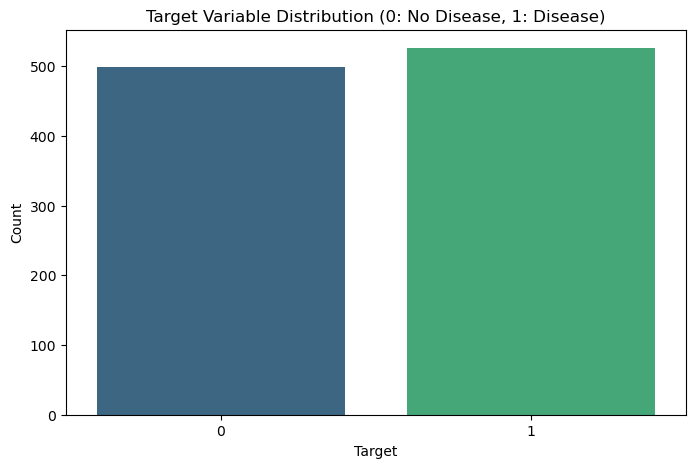

In [7]:
#Target Variable Distribution

plt.figure(figsize=(8, 5))
sns.countplot(x='target', data=data, palette='viridis')
plt.title('Target Variable Distribution (0: No Disease, 1: Disease)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.show()

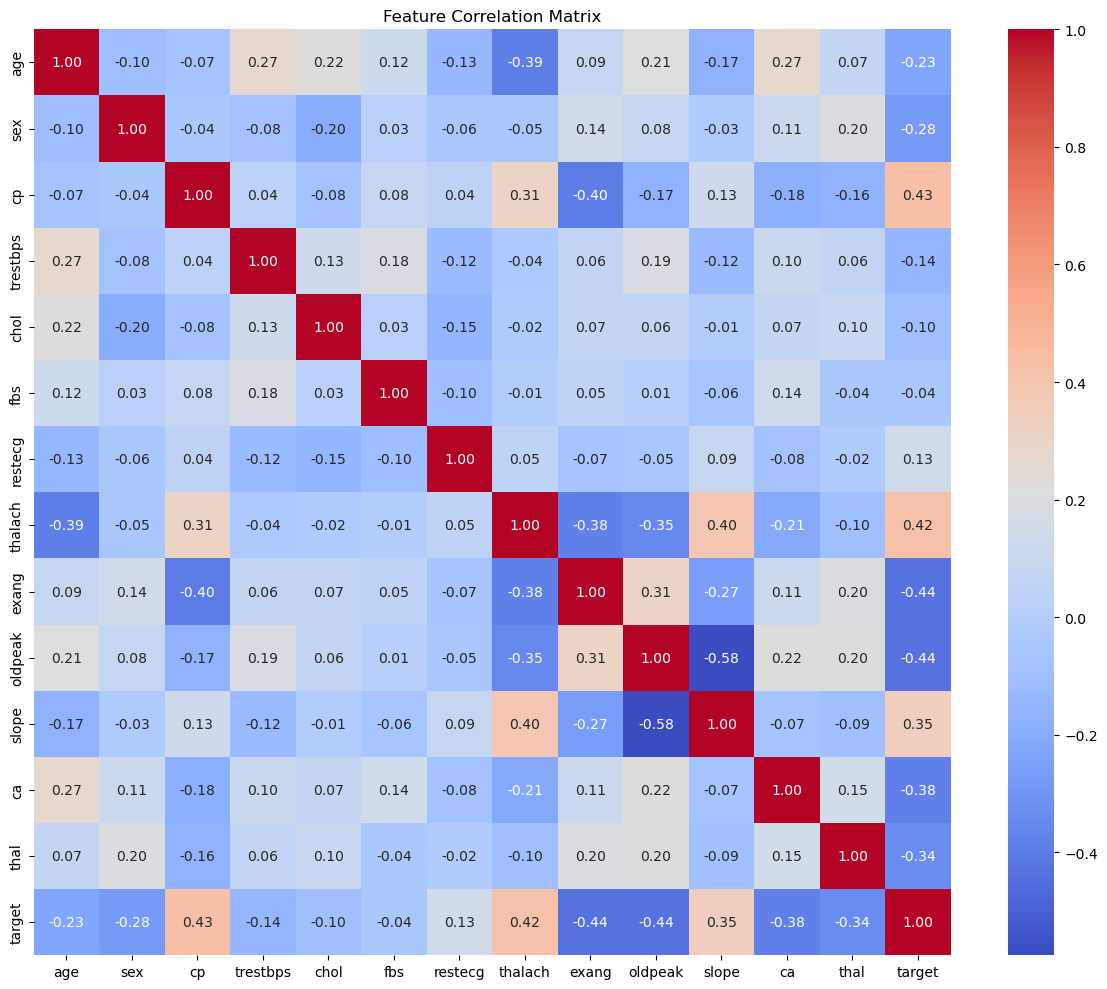

In [8]:
# Correlations Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

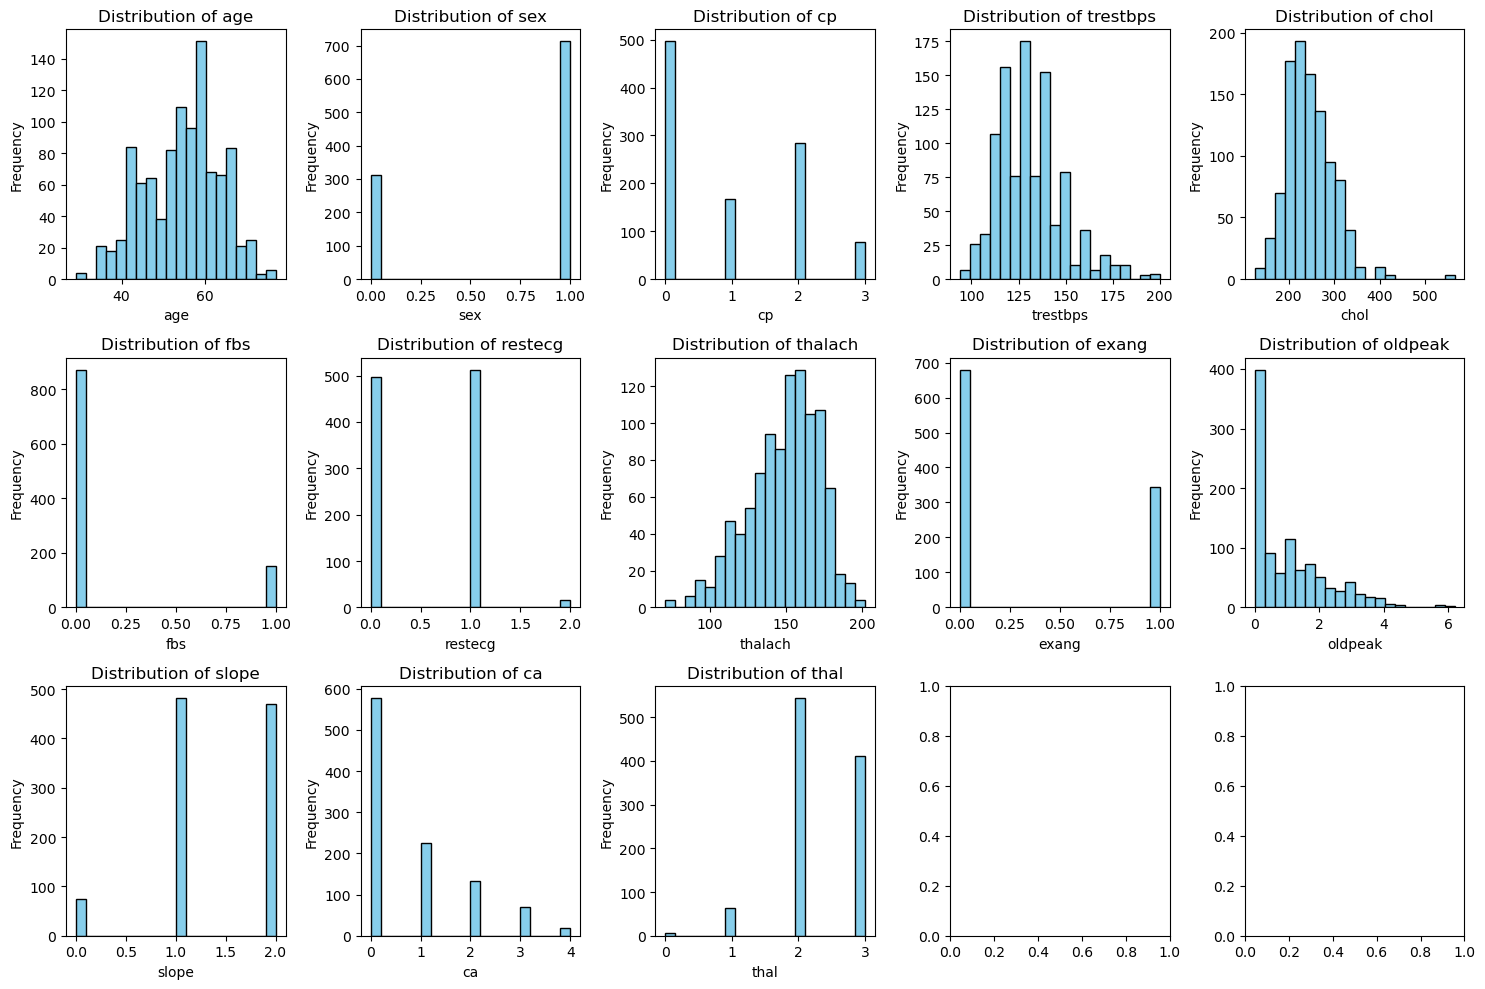

In [9]:
#Feature Distributions
fig, axes = plt.subplots(3, 5, figsize=(15, 10))
axes = axes.ravel()
for idx, col in enumerate(data.columns[:-1]):
    axes[idx].hist(data[col], bins=20, color='skyblue', edgecolor='black')
    axes[idx].set_title(f'Distribution of {col}')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## **Model prepration**

In [10]:
#  Prepare Data - Split into Features and Target
X = data.drop(columns=['target'])
y = data['target']
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (1025, 13)
Target shape: (1025,)


In [11]:
#  Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Training target distribution:\n{y_train.value_counts()}")

Training set size: 820
Test set size: 205
Training target distribution:
target
1    423
0    397
Name: count, dtype: int64


In [12]:
# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features scaled successfully!")
print(f"Training set (scaled) shape: {X_train_scaled.shape}")

Features scaled successfully!
Training set (scaled) shape: (820, 13)


## **ML models**

Here I take different machine learning algorithm and try to find algorithm which predict accurately.

1. Logistic Regression
2. Support Vector Machine
3. Random Forest Classifier
4. XGBOOST


In [13]:
#  Logistic Regression
print("1) LOGISTIC REGRESSION")
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_predictions) * 100
print(f"Accuracy: {lr_accuracy:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, lr_predictions))
print("\nClassification Report:")
print(classification_report(y_test, lr_predictions))
print()

1) LOGISTIC REGRESSION
Accuracy: 79.51%

Confusion Matrix:
[[73 29]
 [13 90]]

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.72      0.78       102
           1       0.76      0.87      0.81       103

    accuracy                           0.80       205
   macro avg       0.80      0.79      0.79       205
weighted avg       0.80      0.80      0.79       205




In [14]:
#  Support Vector Machine
print("2) SUPPORT VECTOR MACHINE (SVM)")
svm_model = SVC(kernel='rbf', C=1.0, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_predictions = svm_model.predict(X_test_scaled)

svm_accuracy = accuracy_score(y_test, svm_predictions) * 100
print(f"Accuracy: {svm_accuracy:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, svm_predictions))
print("\nClassification Report:")
print(classification_report(y_test, svm_predictions))
print()

2) SUPPORT VECTOR MACHINE (SVM)
Accuracy: 88.78%

Confusion Matrix:
[[85 17]
 [ 6 97]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.83      0.88       102
           1       0.85      0.94      0.89       103

    accuracy                           0.89       205
   macro avg       0.89      0.89      0.89       205
weighted avg       0.89      0.89      0.89       205




In [15]:
# Random Forest
print("3) RANDOM FOREST CLASSIFIER")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_predictions = rf_model.predict(X_test_scaled)

rf_accuracy = accuracy_score(y_test, rf_predictions) * 100
print(f"Accuracy: {rf_accuracy:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, rf_predictions))
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))
print()

3) RANDOM FOREST CLASSIFIER
Accuracy: 98.54%

Confusion Matrix:
[[102   0]
 [  3 100]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205




In [16]:
#  XGBoost Classifier
print("4) XGBOOST CLASSIFIER")
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, verbosity=0)
xgb_model.fit(X_train_scaled, y_train)
xgb_predictions = xgb_model.predict(X_test_scaled)

xgb_accuracy = accuracy_score(y_test, xgb_predictions) * 100
print(f"Accuracy: {xgb_accuracy:.2f}%")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_predictions))
print("\nClassification Report:")
print(classification_report(y_test, xgb_predictions))
print()

4) XGBOOST CLASSIFIER
Accuracy: 98.54%

Confusion Matrix:
[[102   0]
 [  3 100]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205




## **Model Comparison**

In [17]:
#  Model Comparison
models_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Support Vector Machine', 'Random Forest', 'XGBoost'],
    'Accuracy': [lr_accuracy, svm_accuracy, rf_accuracy, xgb_accuracy],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1]) * 100,
        roc_auc_score(y_test, svm_model.decision_function(X_test_scaled)) * 100,
        roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:, 1]) * 100,
        roc_auc_score(y_test, xgb_model.predict_proba(X_test_scaled)[:, 1]) * 100
    ]
})

print(models_results.to_string(index=False))
print(f"\nBest Accuracy Model: {models_results.loc[models_results['Accuracy'].idxmax(), 'Model']}")
print(f"Highest Accuracy: {models_results['Accuracy'].max():.2f}%")
print(f"\nBest ROC-AUC Model: {models_results.loc[models_results['ROC-AUC'].idxmax(), 'Model']}")
print(f"Highest ROC-AUC: {models_results['ROC-AUC'].max():.2f}%")

                 Model  Accuracy    ROC-AUC
   Logistic Regression 79.512195  87.873596
Support Vector Machine 88.780488  96.316391
         Random Forest 98.536585 100.000000
               XGBoost 98.536585  98.829240

Best Accuracy Model: Random Forest
Highest Accuracy: 98.54%

Best ROC-AUC Model: Random Forest
Highest ROC-AUC: 100.00%


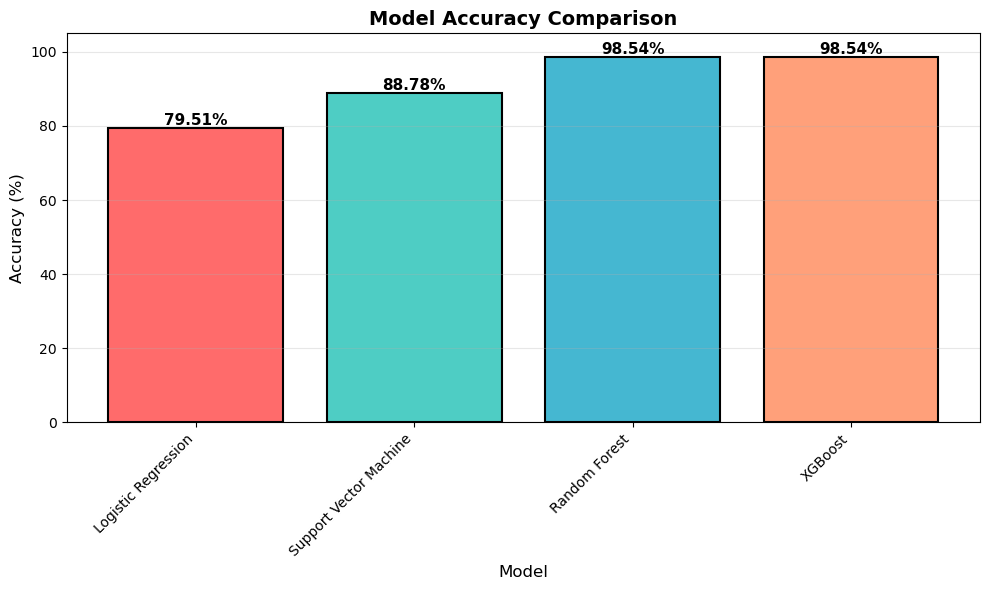

In [18]:
#Accuracy Comparison Chart
plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = plt.bar(models_results['Model'], models_results['Accuracy'], color=colors, edgecolor='black', linewidth=1.5)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim([0, 105])
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

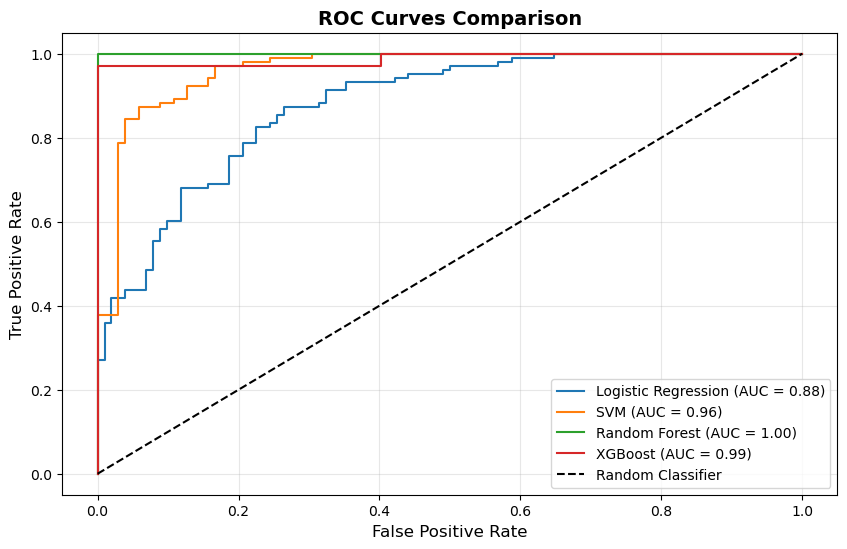

In [19]:
# ROC Curves Comparison
plt.figure(figsize=(10, 6))

# Calculate ROC curves for each model
models_list = [
    ('Logistic Regression', lr_model, lr_model.predict_proba(X_test_scaled)[:, 1]),
    ('SVM', svm_model, svm_model.decision_function(X_test_scaled)),
    ('Random Forest', rf_model, rf_model.predict_proba(X_test_scaled)[:, 1]),
    ('XGBoost', xgb_model, xgb_model.predict_proba(X_test_scaled)[:, 1])
]

for model_name, model, predictions in models_list:
    fpr, tpr, _ = roc_curve(y_test, predictions)
    roc_auc = roc_auc_score(y_test, predictions)
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## Finish Project